In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

## Read the data

In [3]:
!ls *head*.csv

wef_head_of_state.csv


In [4]:
xlabel = 'Years with female head of state'

In [5]:

import os
from extract_pdf_data import read_pdfs

filename = "wef_head_of_state.csv"


In [6]:
from utils import read_wef_file

df = read_wef_file(filename)
df.head()

,country,page_number,score,rank,diff,left,right
code,,,,,,,
ALB,Albania,83,0.000,80,-50.00,0.00,50.00
DZA,Algeria,85,0.000,80,-50.00,0.00,50.00
AGO,Angola,87,0.000,80,-50.00,0.00,50.00
ARG,Argentina,89,0.242,15,-30.53,9.74,40.26
ARM,Armenia,91,0.000,80,-50.00,0.00,50.00


In [7]:
df['rank'].value_counts(dropna=False).head()

rank
80    67
77     2
1      2
37     2
4      1
Name: count, dtype: int64

In [8]:
df['score'].describe()

count    146.000000
mean       0.087568
std        0.170148
min        0.000000
25%        0.000000
50%        0.002500
75%        0.104000
max        1.000000
Name: score, dtype: float64

In [9]:
dinged = df['score'] < 1
dinged.sum()

144

Here is the distribution of their scores.

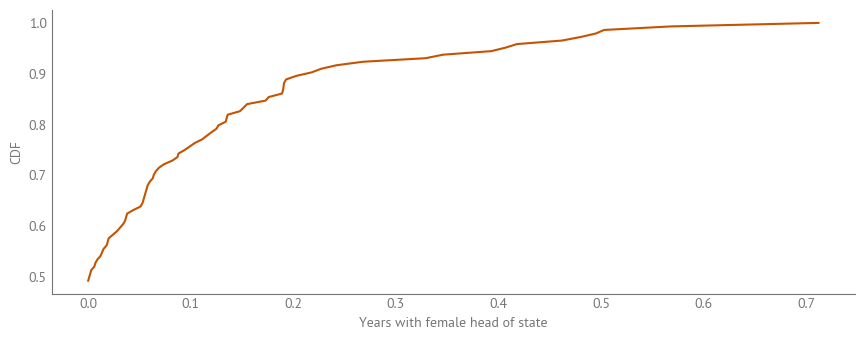

In [10]:
from empiricaldist import Cdf

cdf_score = Cdf.from_seq(df.loc[dinged, 'score'])
cdf_score.plot()
decorate(xlabel=xlabel, ylabel='CDF')

In [11]:
subset = df[dinged]
subset.sort_values("diff", ascending=False)

,country,page_number,score,rank,diff,left,right
code,,,,,,,
IRL,Ireland,211,0.712,3,-8.43,20.79,29.21
NOR,Norway,285,0.568,4,-13.80,18.10,31.90
FIN,Finland,179,0.503,5,-16.55,16.72,33.28
DEU,Germany,187,0.495,6,-16.90,16.55,33.45
NZL,New Zealand,275,0.480,7,-17.58,16.21,33.79
...,...,...,...,...,...,...,...
GHA,Ghana,189,0.000,80,-50.00,0.00,50.00
GMB,Gambia,183,0.000,80,-50.00,0.00,50.00
FJI,Fiji,177,0.000,80,-50.00,0.00,50.00


## Revised scores

The scores are based on ratios, not differences, so let's compute those.

In [12]:
df['ratio'] = df['left'] / df['right']
df['ratio'].describe()

count    146.000000
mean       0.084323
std        0.154829
min        0.000000
25%        0.000000
50%        0.002306
75%        0.104484
max        0.881822
Name: ratio, dtype: float64

Looks like the ratio IS the score.

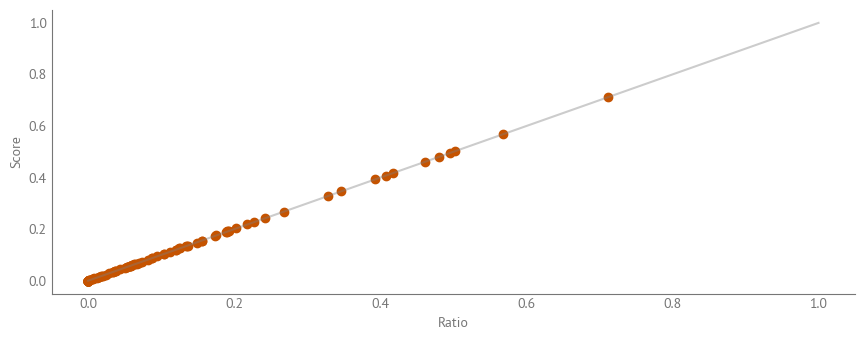

In [13]:
subset = df[dinged]
plt.plot([0, 1], [0, 1], color='gray', alpha=0.4)
plt.scatter(subset['ratio'], subset['score'])
decorate(xlabel='Ratio', ylabel='Score')

So here are the revised, symmetric scores.

In [14]:
df['revised_score'] = df['ratio']
df['revised_score'].describe()

count    146.000000
mean       0.084323
std        0.154829
min        0.000000
25%        0.000000
50%        0.002306
75%        0.104484
max        0.881822
Name: revised_score, dtype: float64

Here's the distribution of revised scores.

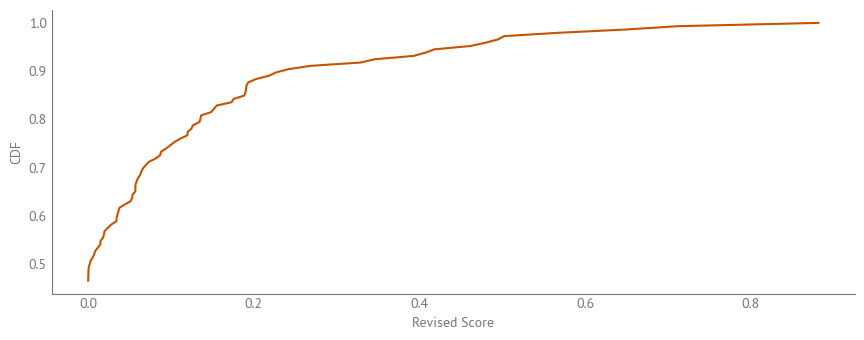

In [15]:
cdf_score = Cdf.from_seq(df['revised_score'])
cdf_score.plot()
decorate(xlabel='Revised Score', ylabel='CDF')

Here's the distribution of revised scores, compare to the original.

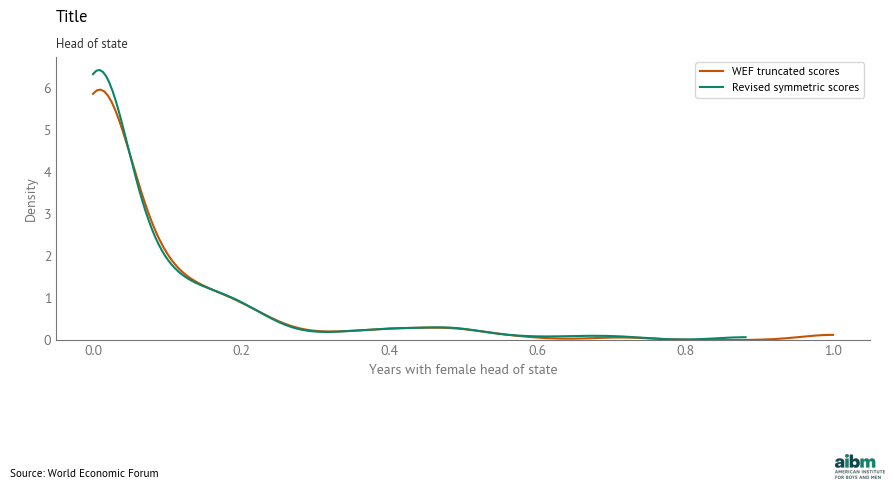

In [28]:
from utils import plot_score_distributions, add_title

plot_score_distributions(df, xlabel=xlabel)
add_title("Title",
          "Head of state")

In [18]:
revised = df[~dinged].dropna(subset=['ratio']).sort_values('revised_score')
revised.shape

(2, 9)

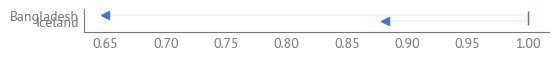

In [19]:
from utils import plot_revised_scores

plot_revised_scores(revised)

## Export the results

In [20]:
from utils import make_rank_table

table = make_rank_table(df)
table.to_csv("wef_head_of_state_table.csv")
table.shape

(146, 6)

In [27]:
table.head()

,country,ratio,rank,revised_rank,score,revised_score
code,,,,,,
ALB,Albania,0.000000,80,79.0,0.000,0.000000
DZA,Algeria,0.000000,80,79.0,0.000,0.000000
AGO,Angola,0.000000,80,79.0,0.000,0.000000
ARG,Argentina,0.241927,15,15.0,0.242,0.241927
ARM,Armenia,0.000000,80,79.0,0.000,0.000000


In [21]:
table['score'].describe()

count    146.000000
mean       0.087568
std        0.170148
min        0.000000
25%        0.000000
50%        0.002500
75%        0.104000
max        1.000000
Name: score, dtype: float64

In [29]:
from utils import make_weight_table

make_weight_table(table, 'head_of_state')

original             revised          
                    std   inv std       std   inv std
head_of_state  0.170148  0.058772  0.154829  0.064587

## OECD countries

In [23]:
from utils import oecd_codes

df_oecd = df.loc[oecd_codes].sort_values(by='revised_score')

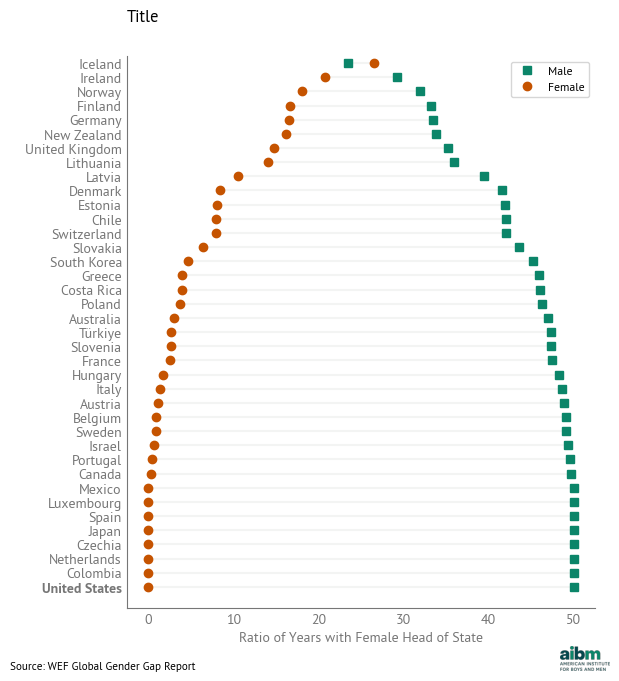

In [30]:
from utils import plot_percentages

plot_percentages(df_oecd)
plt.xlabel('Ratio of Years with Female Head of State')
add_title("Title",
          " ", y=1.01)


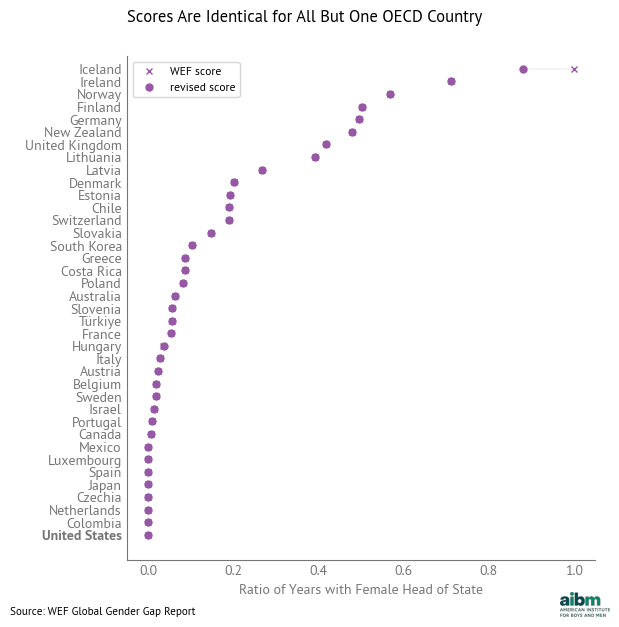

In [31]:
from utils import plot_revised_scores
from utils import add_title, add_subtext, add_logo

plot_revised_scores(df_oecd.sort_values(by='score', ascending=False))
decorate(xlabel='Ratio of Years with Female Head of State')
add_title('Scores Are Identical for All But One OECD Country',
          '', y=1.02)
add_subtext('Source: WEF Global Gender Gap Report', y=-0.01)
logo = add_logo(location=(1.0, -0.01))

In [32]:
df.query("country == 'Iceland'")

,country,page_number,score,rank,diff,left,right,ratio,revised_score,revised_rank
code,,,,,,,,,,
ISL,Iceland,203,1.0,1,3.15,23.43,26.57,0.881822,0.881822,1.0
